In [3]:
import numpy as np
import tqdm
import os
import re
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
import yt
yt.set_log_level("error")
import sys
sys.path.append('../../sedov_theory/python/')
from sedov_theory import SedovTalorProblem

In [4]:
run_dir = '../run'
file_start = 'plt_2d_'

# 2D SlicePlot of the blast


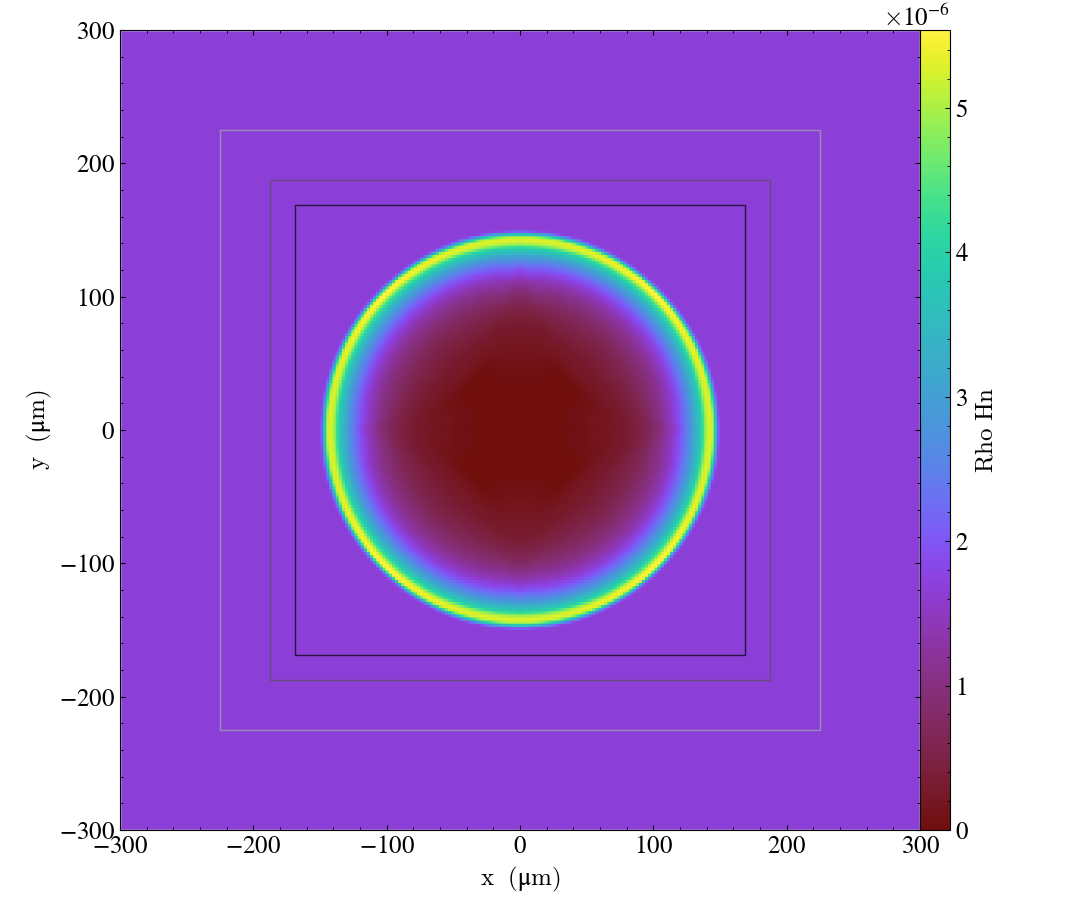

In [5]:
ds = yt.load('../run/plt_2d_00100/', hint="castro")
quantity = 'rho_Hn'
sl = yt.SlicePlot(ds, 'z', quantity)
sl.set_log(quantity, False)
sl.annotate_grids()


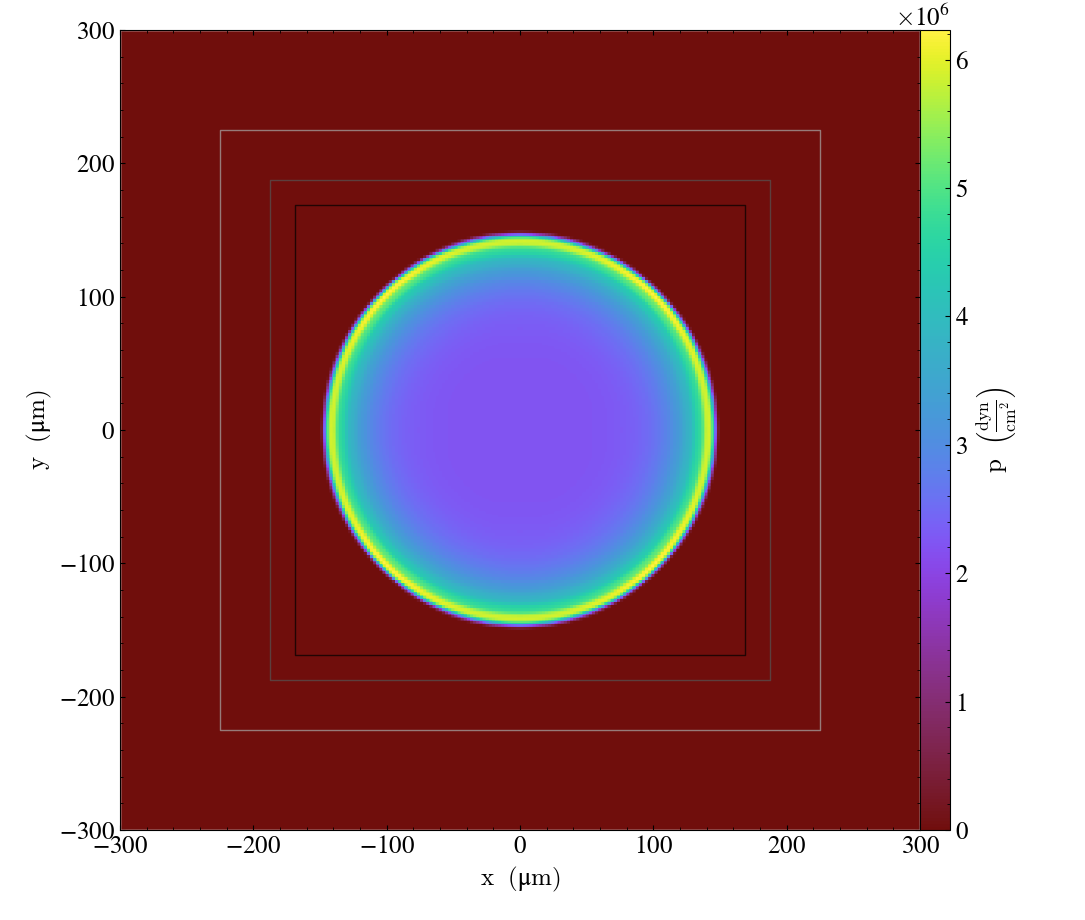

In [6]:
ds = yt.load('../run/plt_2d_00100/', hint="castro")
quantity = 'pressure'
sl = yt.SlicePlot(ds, 'z', quantity)
sl.set_log(quantity, False)
sl.annotate_grids()

# Compare data with theory

In [10]:
# Calculate analytical solution
gamma = 5./3
rho = 1.67e-6 # g / cm^3
E = 4400 # erg / cm

sol = SedovTalorProblem(gamma, E, rho)

In [11]:
# First: allow files to be readable by yt in 1D
# yt refuses to read files that are cylindrical in 1D geometry
# therefore, we remove the corresponding flag here
if '1d' in file_start:
    for filename in os.listdir(run_dir):
        if filename.startswith(file_start):
            header_file = os.path.join(run_dir, filename, 'Header')
            # Read file
            with open(header_file) as f:
                text = f.read()
            # Replace the flag that indicates cylindrical geometry
            text = re.sub('(0\.\d+) \n1\n0', '\g<1> \n0\n0', text)
            # Write file
            with open(header_file, 'w') as f:
                f.write(text)  

In [12]:
def extract_data( iteration, quantity, level ):
    filename = os.path.join( run_dir, file_start + '%05d' %iteration )
    ds = yt.load( filename, hint="castro")
    if '1d' in file_start:
        ad = ds.covering_grid( level=level, 
                           left_edge=ds.domain_left_edge, 
                           dims=[ds.domain_dimensions[0]*2**level, 1, 1] )   
        q = ad[quantity].to_ndarray().squeeze()
        r = np.linspace(
            ds.domain_left_edge[0],
            ds.domain_right_edge[0],
            ds.domain_dimensions[0]*2**level)       
    elif '2d'in file_start:
        ad = ds.covering_grid( level=level, 
                               left_edge=ds.domain_left_edge, 
                               dims=[ds.domain_dimensions[0]*2**level, ds.domain_dimensions[1]*2**level, 1] )
        q = ad[quantity].to_ndarray().squeeze()
        q = q[q.shape[0]//2:,q.shape[1]//2]
        r = np.linspace(
            0.5*(ds.domain_left_edge[0] + ds.domain_right_edge[0]),
            ds.domain_right_edge[0],
            ds.domain_dimensions[0]*2**level//2)
        r -= 0.5*(ds.domain_left_edge[0] + ds.domain_right_edge[0])
    return r.to_ndarray(), q, ds.current_time.to_value()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 128/128 [00:00<00:00, 43170.71it/s]


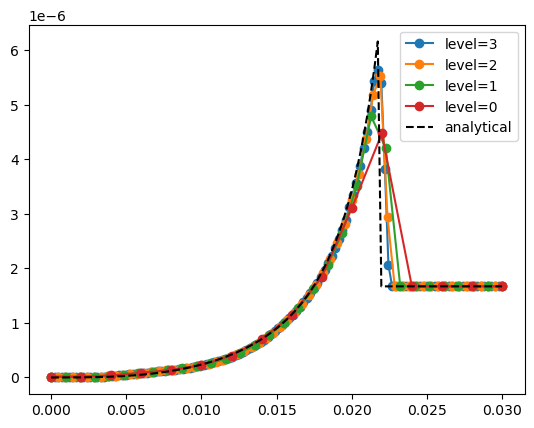

In [13]:
# plot data at difference resolutions
quantity = 'density'

plt.clf()
for level in range(3,-1,-1):
    r, q, t = extract_data( 150, quantity, level)
    plt.plot(r, q, '-o', label='level=%d'%level)
    if level == 3:
        r_th = r
        t_th = t
plt.plot( r_th, sol.evaluate( quantity, r_th, t_th ), 'k--', label='analytical' )
plt.legend(loc=0)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 128/128 [00:00<00:00, 45397.51it/s]


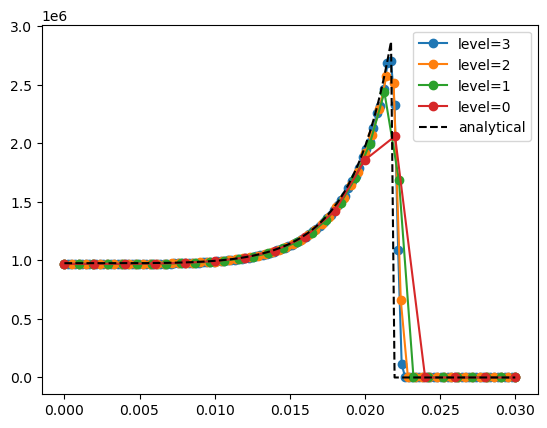

In [14]:
# plot data at difference resolutions
quantity = 'pressure'

plt.clf()
for level in range(3,-1,-1):
    r, q, t = extract_data( 150, quantity, level)
    plt.plot(r, q, '-o', label='level=%d'%level)
    if level == 3:
        r_th = r
        t_th = t
plt.plot( r_th, sol.evaluate( quantity, r_th, t_th ), 'k--', label='analytical' )
plt.legend(loc=0)

In [15]:
# Extract data from different time 
# Note that time is not regularly spaced
t_arr = []
q_arr = []
rmax_arr = []
iterations = sorted([ int(filename[-5:]) 
                     for filename in os.listdir(run_dir) 
                     if filename.startswith(file_start) ])
for iteration in tqdm.tqdm(iterations):
    r, q, t = extract_data(iteration, 'density', level=2)
    rmax = r[np.argmax(q)]
    t_arr.append(t)
    rmax_arr.append(rmax)
    q_arr.append(q)
q_arr = np.stack(q_arr)
t_arr = np.array(t_arr)
r_arr = r

# Interpolate on a grid with regularly-spaced time
interp = RegularGridInterpolator(points=(t_arr, r_arr), values=q_arr, bounds_error=False, fill_value=None)
t_interp, r_interp = np.meshgrid(
    np.linspace(0, t_arr.max(), 1000), 
    np.linspace(0, r_arr.max(), 1000), indexing='ij')
q_interp = interp((t_interp, r_interp))

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 38/38 [00:08<00:00,  4.71it/s]


Text(0.5, 0, 't (s)')

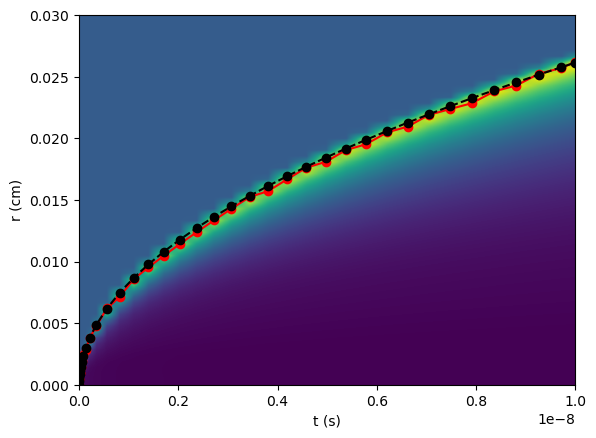

In [16]:
plt.imshow(q_interp.T, origin='lower', extent=[0, t_arr.max(), 0, r_arr.max()], aspect='auto')
plt.plot(t_arr, rmax_arr, 'r-o')
r_analytical = sol.blast_radius(t_arr)
plt.plot(t_arr, r_analytical, 'k--o')
plt.ylabel('r (cm)')
plt.xlabel('t (s)')